In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Experiment: MobileNetV2 + Triplet Loss - 20 Authors

Author identification experiment on handwritten documents using **Siamese Networks with Triplet Loss**.

**Objetive**: learn dn embedding space where patches from the same author cluster together and patches from different authors are pushed apart, enabling identification by similarity.

**Experiment setup**:
- Dataset: variant 4 (lines removed, grayscale)
- Authors: 20 (range 20)
- Architecture: MobileNetV2 fine-tuned + embedding head + triplet siamese network.

In [2]:
import os
import shutil
import datetime
import gc
import numpy as np
import tensorflow as tf
import random
from typing import Literal
import matplotlib.pyplot as plt
import pandas as pd
import math
from dataclasses import dataclass
from collections.abc import Iterable
from sklearn.metrics import (
    confusion_matrix,
    roc_curve,
    precision_recall_curve,
    roc_auc_score,
)
import seaborn as sns

In [3]:
!pip install "zarr>=2.16.0,<3.0.0" numcodecs umap-learn

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.3/211.3 kB 20.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 134.3 MB/s eta 0:00:00
  Created wheel for asciitree: filename=asciitree-0.3.3-py3-none-any.whl size=5031 sha256=2f2929d002211f8dab0d6f1c22dedb1277468159ed4ff8df14d43456193caf05
  Stored in directory: /root/.cache/pip/wheels/a5/d7/98/f56ae733748cd0fa577172bda0e73e0b1f1793c98e09b9e458
Successfully built asciitree


## Configuration

Configuration is split into dataclasses by domain of responsibility:

- ModelConfig - siamese network type (pair o triplet)
- `DataConfig` - selected authors and image shapes
- TrainingConfig - training hyperparameters
- BatchConfig - batch sizes per split

**Key decisions**:
- val_ratio=0.25 - fraction on non-test data reserved for validation
- epochs=30 - maximum training epochs (early stopping may trigger earlier)

In [4]:
ModelType = Literal["pair", "triplet"]

@dataclass
class ModelConfig:
    type: ModelType

@dataclass
class DataConfig:
    authors_range: Iterable[int]
    original_shape: tuple[int, int, int]
    model_input_shape: tuple[int, int, int]

    def __post_init__(self):
        authors_array = np.asarray(list(self.authors_range))

        if authors_array.ndim != 1 or len(authors_array) == 0:
            raise ValueError("authors_range must be a non-empty 1D iterable")

        if len(np.unique(authors_array)) != len(authors_array):
            raise ValueError("authors_range contains duplicates")

        self.authors_range = authors_array
        self.authors = len(authors_array)


@dataclass
class TrainingConfig:
    epochs: int
    seed: int
    val_ratio: float

    def __post_init__(self):
        assert 0 < self.val_ratio < 1, "val_ratio must be between 0 and 1"


@dataclass
class BatchConfig:
    train: int
    validation: int
    test: int

    def __post_init__(self):
        assert self.train > 0
        assert self.validation > 0
        assert self.test > 0


@dataclass
class Config:
    project_path: str
    dataset: str
    model: ModelConfig
    data: DataConfig
    training: TrainingConfig
    batch: BatchConfig
    current_time: str

In [5]:
config = Config(
    project_path='drive/MyDrive/author-handwriting-recog',
    dataset='dataset_4_ImagesLinesRemoved_20260310-153450',
    model=ModelConfig(type="triplet"),
    data=DataConfig(
        authors_range=range(0, 20),
        original_shape=(180, 360, 1),
        model_input_shape=(120, 240, 3),
    ),
    training=TrainingConfig(
        epochs=25,
        seed=42,
        val_ratio=0.25
    ),
    batch=BatchConfig(
        train=16,
        validation=8,
        test=4,
    ),
    current_time=datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
)

In [6]:
def upload_source(source: str, source_dest: str):
    if os.path.exists(source_dest):
        shutil.rmtree(source_dest)

    shutil.copytree(source, source_dest)

In [7]:
upload_source(
    source=f"{config.project_path}/src",
    source_dest="./src"
)

In [8]:
upload_source(
    source=f"{config.project_path}/data/datasets/180_360_90",
    source_dest=f"./dataset"
)

In [9]:
upload_source(
    source=f"{config.project_path}/data/datasets/experiments",
    source_dest="./models"
)

In [10]:
random.seed(config.training.seed)
np.random.seed(config.training.seed)
tf.random.set_seed(config.training.seed)

In [11]:
from src.io import LoggerFactory
from src.datasets.loaders import SelectiveDataLoader
from src.generators import (
    AugmentationPipeline,
    AugmentationOps,
    AugmentImage,
    BaseGenerator,
    DataGenerator,
    TripletGenerator,
)

In [12]:
from src.models import (
    MobileNetV2Backbone,
    TripletLoss,
    EmbeddingNetwork,
    SiameseFactory
)
from src.training import (
    get_default_callbacks,
    ModelTrainerFactory,
    BaseMetricTrainer,
)
from src.evaluator import (
    TripletEvaluator,
    EmbeddingEvaluator,
    EmbeddingVisualizer,
)

In [13]:
from src.evaluator.embedding_utils import EmbeddingExtractor
from src.evaluator.embedding_strategy import (
    StrategyPipeline,
    OneNNStrategy,
    MeanStrategy,
    CentroidStrategy,
    TopKStrategy,
    PatchAggregator,
    VoteAggregator,
    ScoreAggregator,
)

In [14]:
logger = LoggerFactory.get_logger(
    "mobile_test_20_4",
    log_dir=f"./logs_{config.current_time}",
    file_prefix=f"mobile_triplet_{config.current_time}"
)

In [15]:
dataset_path = f"dataset/{config.dataset}.tar.gz"

In [16]:
!tar -xzf {dataset_path} -C ./

## Dataset

The dataset is stored in .zarr format with spatial separation between train and test:

```
dataset.zarr
├── non_test/   ← patches from the main writing area (train + val)
└── test/       ← patches from the test area, physically separated in the original image
```

`SelectiveDataLoader` selects a subset of authors and builds the three splits (train, val, test) guaranteeing that **no patch from the test area appears in train o val**.
This eliminates data leakage by spatial position.

In [17]:
loader = SelectiveDataLoader(
    dataset_path=f"./{config.dataset}.zarr",
    logger=logger,
    seed=config.training.seed
)

In [18]:
train, val, test = loader.build(
      authors=config.data.authors_range,
      validation_fraction=config.training.val_ratio,
  )

10:41:53 - mobile_test_20_4 - INFO - Total patches selected: 12792
10:41:53 - mobile_test_20_4 - INFO - Train: 9594 | Val: 3198 | Test: 859
10:41:53 - mobile_test_20_4 - INFO - Avg non_test patches per author: 639.60 | Min: 467 | Max: 805
10:41:53 - mobile_test_20_4 - INFO - Avg test patches per author: 42.95 | Min: 34 | Max: 47
10:41:53 - mobile_test_20_4 - INFO - Image shape: (180, 360)
10:41:53 - mobile_test_20_4 - INFO - Zarr chunk shape: (64, 180, 360)


## Augmentation

Two distinct pipelines are used:

- **pipeline_train** - full augmentation: rotation, zoom, shift, noise, brightness, contrast
- **pipeline** - resize _ normalization only (no perturbations)

The training pipeline introduces artificial variability to improve generaliaztion. The validation/test pipeline is deterministic for reproducible evaluation.

> mobilenet_preprocess at the end is required - it normalizes pixel values to the range
> expected by MobileNetV2 (ImageNet statistics)

In [19]:
ops = AugmentationOps(
    rotation_range=6,
    width_shift_range=0.04,
    height_shift_range=0.05,
    horizontal_flip=False,
    resize_dim=config.data.model_input_shape[:2],
    brightness_delta=0.04,
    contrast_range=(0.95, 1.05),
    noise_stddev=0.01,
    zoom_range=(0.95, 1.05),
)
pipeline_train = AugmentationPipeline([
    ops.rotate,
    ops.zoom,
    ops.shift,
    ops.resize,
    ops.to_rgb,
    ops.clip_255,
    ops.mobilenet_preprocess,
])
pipeline = AugmentationPipeline([
    ops.resize,
    ops.to_rgb,
    ops.clip_255,
    ops.mobilenet_preprocess,
])
augment_train = AugmentImage(pipeline_train)
augment = AugmentImage(pipeline)

In [20]:
train_triplet = TripletGenerator(
    split=train,
    batch_size=config.batch.train,
    seed=config.training.seed,
    augment=augment_train
)
val_triplet = TripletGenerator(
    split=val,
    batch_size=config.batch.validation,
    seed=config.training.seed,
    augment=augment
)
test_triplet = TripletGenerator(
    split=test,
    batch_size=config.batch.test,
    seed=config.training.seed,
    augment=augment
)

In [21]:
def display_generator_info(generator: BaseGenerator):
    config = generator.get_config()
    logger.info(f"Generator: {generator.__class__.__name__}")
    logger.info(f"Number of samples: {config['num_samples']}")
    logger.info(f"Batch size: {config['batch_size']}")
    logger.info(f"Steps per epoch: {config['steps_per_epoch']}")
    logger.info(f"Shape: {config['patch_shape']}")
    logger.info(f"Number of authors: {config['num_authors']}")

In [22]:
display_generator_info(train_triplet)

10:42:16 - mobile_test_20_4 - INFO - Generator: TripletGenerator
10:42:16 - mobile_test_20_4 - INFO - Number of samples: 9594
10:42:16 - mobile_test_20_4 - INFO - Batch size: 16
10:42:16 - mobile_test_20_4 - INFO - Steps per epoch: 600
10:42:16 - mobile_test_20_4 - INFO - Shape: (180, 360)
10:42:16 - mobile_test_20_4 - INFO - Number of authors: 20


In [23]:
display_generator_info(val_triplet)

10:42:18 - mobile_test_20_4 - INFO - Generator: TripletGenerator
10:42:18 - mobile_test_20_4 - INFO - Number of samples: 3198
10:42:18 - mobile_test_20_4 - INFO - Batch size: 8
10:42:18 - mobile_test_20_4 - INFO - Steps per epoch: 400
10:42:18 - mobile_test_20_4 - INFO - Shape: (180, 360)
10:42:18 - mobile_test_20_4 - INFO - Number of authors: 20


In [24]:
display_generator_info(test_triplet)

10:42:19 - mobile_test_20_4 - INFO - Generator: TripletGenerator
10:42:19 - mobile_test_20_4 - INFO - Number of samples: 859
10:42:19 - mobile_test_20_4 - INFO - Batch size: 4
10:42:19 - mobile_test_20_4 - INFO - Steps per epoch: 215
10:42:19 - mobile_test_20_4 - INFO - Shape: (180, 360)
10:42:19 - mobile_test_20_4 - INFO - Number of authors: 20


## Model Construction

The architecture follows a chain of separated responsibilities:

```
MobileNetV2Backbone         → extracts visual features (pre-trained on ImageNet)
    ↓
EmbeddingNetwork            → projects features to an L2-normalized embedding space
    ↓
SiameseFactory              → builds the triplet siamese network (anchor, positive, negative)
    ↓
ModelTrainerFactory         → wraps the network in a trainer with training/eval logic
```

**`trainer.siamese_network`** — full triplet network, used during training.
**`trainer.embedding_model`** — backbone + embedding head, used to extract embeddings at evaluation time.
Both share the same weights in memory.

In [25]:
embedding_network = EmbeddingNetwork(
    backbone=MobileNetV2Backbone(freeze_base=False, fine_tune_at=100),
    input_shape=config.data.model_input_shape,
    num_authors=config.data.authors,
)

In [26]:
siamese_builder = SiameseFactory.create(
    model_type=config.model.type,
    embedding_network=embedding_network,
    input_shape=config.data.model_input_shape,
)

In [27]:
trainer = ModelTrainerFactory.create(
    siamese_builder=siamese_builder,
    train_generator=train_triplet,
    val_generator=val_triplet,
    model_name="mobilenet_triplet",
    model_type=config.model.type,
)

In [28]:
trainer.initialize_model()

/content/src/models/backbones/mobile_net.py:13: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


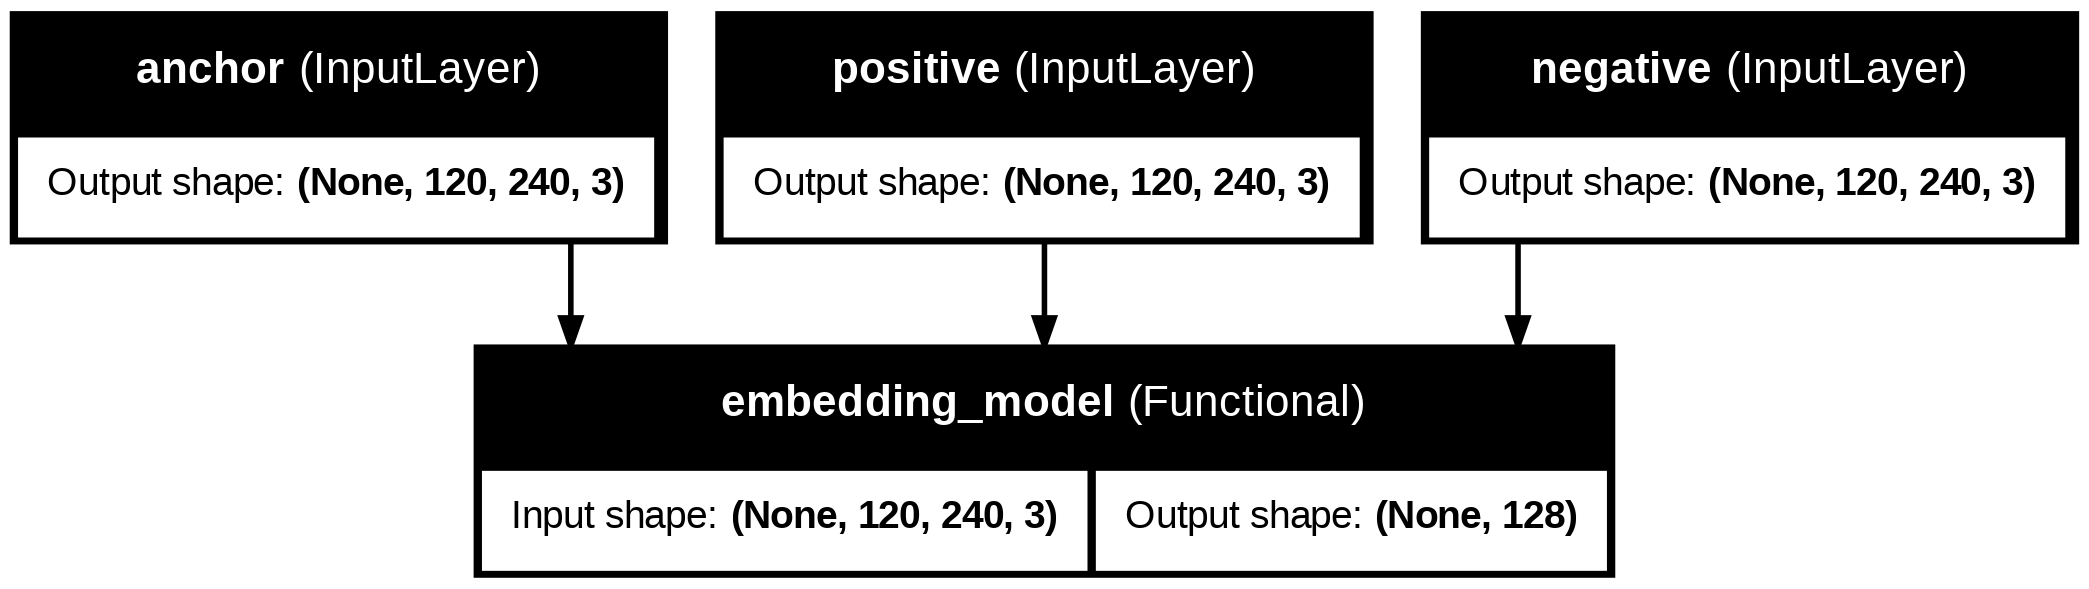

In [ ]:
tf.keras.utils.plot_model(
    trainer.siamese_network,
    show_shapes=True,
    show_layer_names=True,
)

In [30]:
trainer.siamese_network.summary()

Model: "siamese_triplet_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ anchor (InputLayer) │ (None, 120, 240,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positive            │ (None, 120, 240,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ negative            │ (None, 120, 240,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_model     │ (None, 128)       │  2,620,352 │ anchor[0][0],     │
│ (Functional)        │                   │            │ positive[0][0],   │
│                     │                   │            │ negative[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,620,352 (10.00 MB)

 Trainable params: 2,223,040 (8.48 MB)

 Non-trainable params: 397,312 (1.52 MB)

In [31]:
trainer.embedding_model.summary()

Model: "embedding_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 120, 240, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 4, 8, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ l2_normalization                │ (None, 128)            │             0 │
│ (L2Normalization)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,620,352 (10.00 MB)

 Trainable params: 2,223,040 (8.48 MB)

 Non-trainable params: 397,312 (1.52 MB)

## Compilation and Training

**TripletLoss** with margin=0.4:
minimizes max(d(a, p) - d(a, n) + margin, 0) where d is cosine distance.

**Monirored metrics**:
- ap_sim - average cosine similarity between anchor and positive (want: high)
- an_sim - average cosine similarity between anchor and negative (want: low)
- margin - difference ap_sim - an_sim (want: positive and increasin)
- triplet_acc - fraction of triplets where ap_sim > an_sim

**Callbacks**:
- EarlyStopping(patience=4) - stops training if vall_loss does not improve
- ReduceLROPlateau(patience=2) - reduces learning rate on plateau
- start_from_epoch=5 - early stopping is inactive during warm-up epochs

In [29]:
trainer.compile(
    loss=TripletLoss(margin=0.4),
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    metrics=[
        tf.keras.metrics.Mean(name="ap_sim"),
        tf.keras.metrics.Mean(name="an_sim"),
        tf.keras.metrics.Mean(name="margin"),
        tf.keras.metrics.Mean(name="triplet_acc"),
    ],
)

In [ ]:
callbacks = get_default_callbacks(
    model_name="mobile_siamese_triplet",
    monitor="val_loss",
    mode="min",
    patience=4,
    start_from_epoch=5,
    reduce_lr_patience=2,
)

In [ ]:
history = trainer.train_model(
    epochs=config.training.epochs,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/25
600/600 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - an_sim: 0.0011 - ap_sim: 0.0333 - loss: 0.3690 - margin: 0.0322 - triplet_acc: 0.5664
Epoch 1: val_loss improved from None to 0.33086, saving model to checkpoints/mobile_siamese_triplet/best.keras

Epoch 1: finished saving model to checkpoints/mobile_siamese_triplet/best.keras
600/600 ━━━━━━━━━━━━━━━━━━━━ 175s 193ms/step - an_sim: -0.0013 - ap_sim: 0.0449 - loss: 0.3563 - margin: 0.0462 - triplet_acc: 0.5925 - val_an_sim: 0.0865 - val_ap_sim: 0.1625 - val_loss: 0.3309 - val_margin: 0.0761 - val_triplet_acc: 0.6304 - learning_rate: 1.0000e-05
Epoch 2/25
599/600 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - an_sim: -0.0046 - ap_sim: 0.1103 - loss: 0.3026 - margin: 0.1148 - triplet_acc: 0.6723
Epoch 2: val_loss improved from 0.33086 to 0.27583, saving model to checkpoints/mobile_siamese_triplet/best.keras

Epoch 2: finished saving model to checkpoints/mobile_siamese_triplet/best.keras
600/600 ━━━━━━━━━━━━━━━━━━━━ 48s 80ms/step - an_sim: -0.005

In [ ]:
def plot_keras_history(history: tf.keras.callbacks.History):

    df = pd.DataFrame(history.history)

    metrics = [col for col in df.columns if not col.startswith("val_")]

    n_metrics = len(metrics)
    n_cols = 2
    n_rows = math.ceil(n_metrics / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5 * n_rows))
    axes = axes.flatten()

    for i, metric in enumerate(metrics):
        ax = axes[i]

        ax.plot(df[metric], label=f"train_{metric}")

        val_metric = f"val_{metric}"
        if val_metric in df.columns:
            ax.plot(df[val_metric], label=f"val_{metric}")

        ax.set_title(metric)
        ax.set_xlabel("Epoch")
        ax.legend()

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

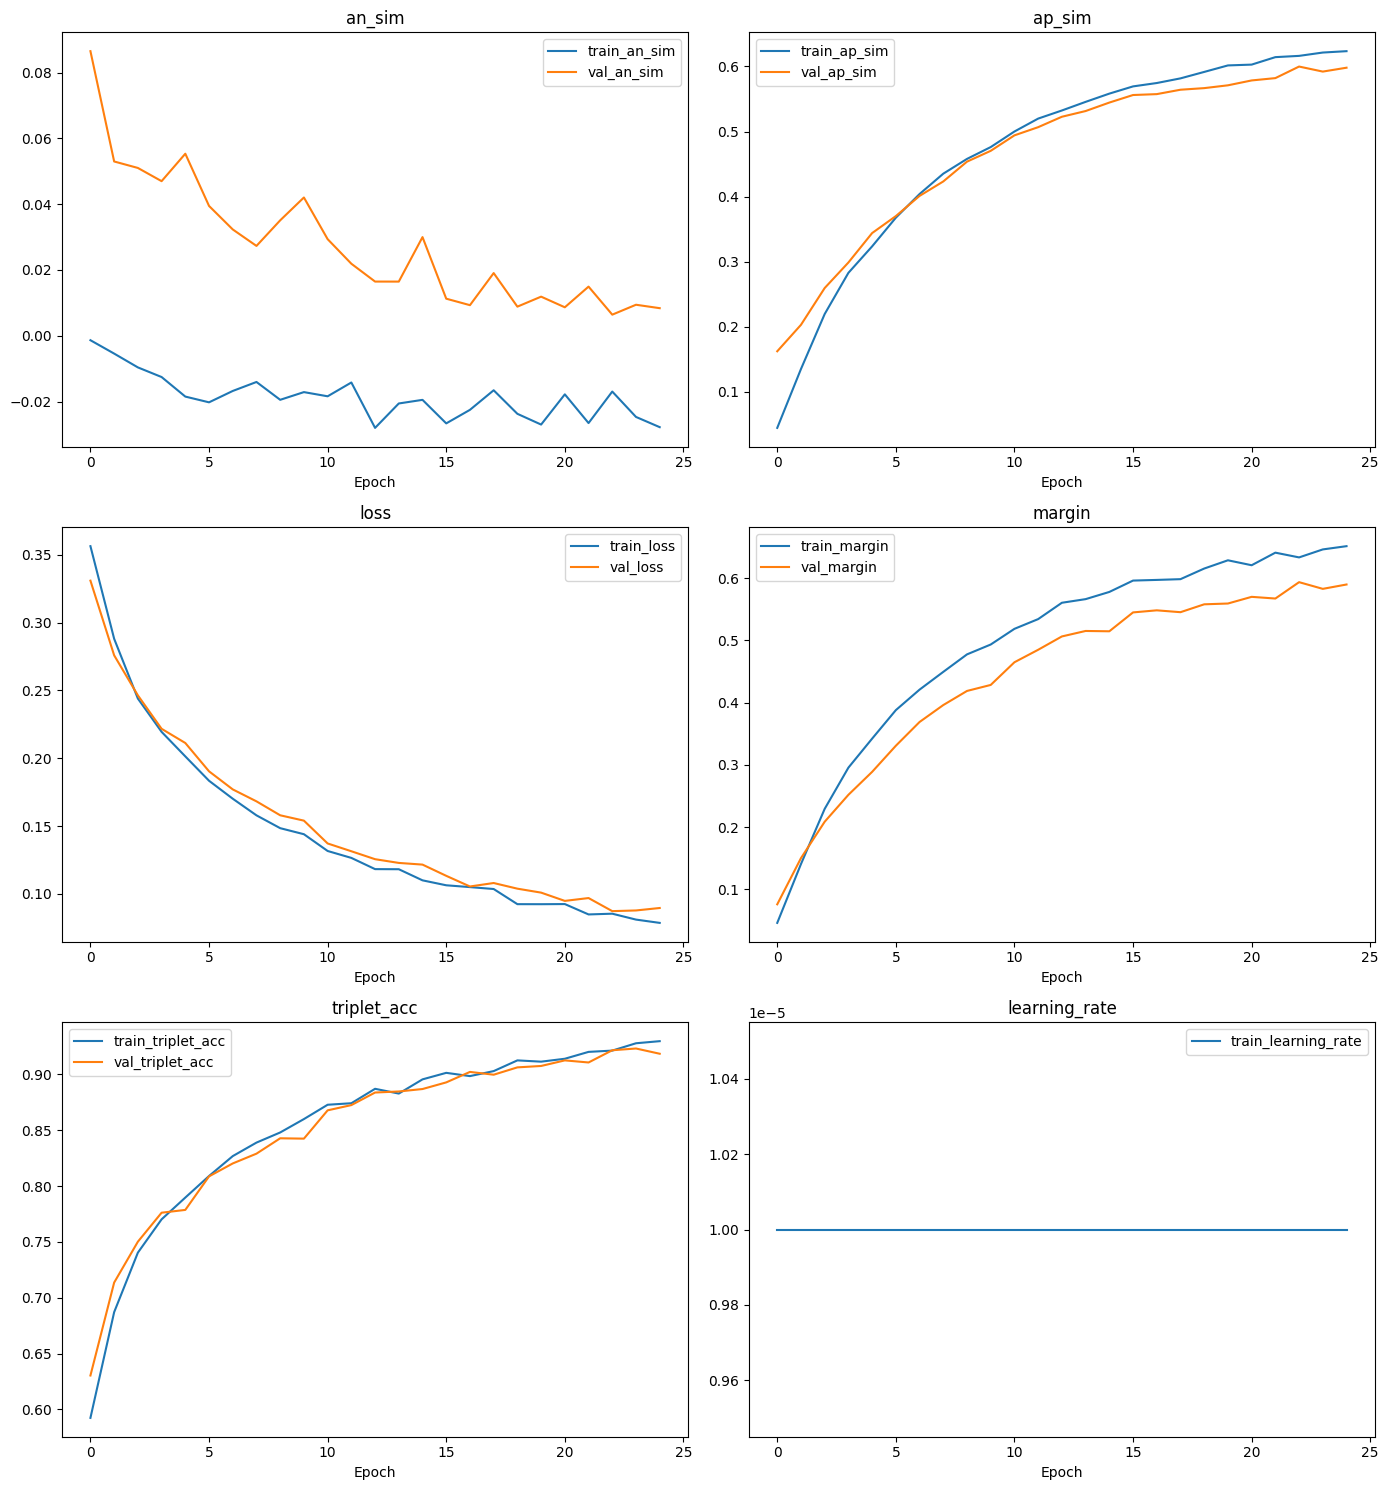

In [ ]:
plot_keras_history(history)

In [ ]:
def save_model(model: BaseMetricTrainer, path: str):
    model.siamese_network.save(f"{path}/mobilenet_siamese_model_20_{config.current_time}.keras")
    model.embedding_model.save(f"{path}/mobilenet_embedding_model_20_{config.current_time}.keras")

In [ ]:
save_model(model=trainer, path="./models")

In [ ]:
save_model(model=trainer, path=f"./{config.project_path}/data/datasets/experiments")

In [30]:
trainer.siamese_network.load_weights("./models/mobilenet_siamese_model_20_20260326-112800.keras")

In [ ]:
metrics_val = trainer.evaluate_dict(val_triplet)
metrics_val

400/400 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - an_sim: -0.0012 - ap_sim: 0.5913 - loss: 0.0873 - margin: 0.5925 - triplet_acc: 0.9234


{'an_sim': -0.0011995817767456174,
 'ap_sim': 0.5913262963294983,
 'loss': 0.0872974693775177,
 'margin': 0.5925259590148926,
 'triplet_acc': 0.9233896136283875}

In [ ]:
metrics_test = trainer.evaluate_dict(test_triplet)
metrics_test

215/215 ━━━━━━━━━━━━━━━━━━━━ 36s 90ms/step - an_sim: -0.0135 - ap_sim: 0.6552 - loss: 0.0651 - margin: 0.6688 - triplet_acc: 0.9488


{'an_sim': -0.013534558936953545,
 'ap_sim': 0.65523761510849,
 'loss': 0.06506955623626709,
 'margin': 0.6687719225883484,
 'triplet_acc': 0.9487776756286621}

In [31]:
def build_author_confusion_matrix(
    df: pd.DataFrame,
    true_col: str = "author_i",
    pred_col: str = "author_j"
) -> pd.DataFrame:
    authors = sorted(df[true_col].unique())

    cm = confusion_matrix(
        df[true_col],
        df[pred_col],
        labels=authors
    )

    cm_df = pd.DataFrame(
        cm,
        index=authors,
        columns=authors
    )

    return cm_df

In [32]:
def display_heatmap(
    df: pd.DataFrame,
    title: str = "Confusion Matrix",
    show_accuracy: bool = True,
) -> None:
    """
    Display confusion matrix heatmap with optional accuracy in title.
    """

    if show_accuracy:
        correct = np.trace(df.values)
        total = df.values.sum()
        acc = correct / total if total > 0 else 0.0

        title = f"{title} (Acc={acc:.3f})"

    plt.figure(figsize=(10, 8))
    sns.heatmap(df, cmap="Blues", linewidths=0.5)

    plt.xlabel("Predicted Author")
    plt.ylabel("True Author")
    plt.title(title)

    plt.show()

## Triplet Evaluation

`TripletEvaluator` evaluates the model in terms of **pairwise similarity**:

- Generates triplets (anchor, positive, negative) from the test set
- Computes cosine similarity between anchor-positive and anchor-negative pairs
- **AUC** — ability to discriminate similar pairs from dissimilar ones
- **Triplet accuracy** — % of triplets where `sim(a,p) > sim(a,n)`

This evaluation measures the quality of the similarity space,
independently of the author identification strategy.

In [33]:
triplet_evaluator = TripletEvaluator(
    siamese_network=trainer.siamese_network,
    logger=logger,
)

In [34]:
triplet_evaluator.data_generator = test_triplet
triplet_report = triplet_evaluator.evaluate()

10:45:09 - mobile_test_20_4 - INFO - === Triplet Evaluation Started ===
10:45:11 - mobile_test_20_4 - INFO - === Collecting triplet results ===
10:45:24 - mobile_test_20_4 - INFO - Total triplets collected: 215
10:45:24 - mobile_test_20_4 - INFO - [LOCAL] acc=0.9441 gap=0.6731 error=0.0559 auc=0.9438
10:45:24 - mobile_test_20_4 - INFO - === Computing global metrics ===
10:45:24 - mobile_test_20_4 - INFO - === Global metrics computed ===
10:45:24 - mobile_test_20_4 - INFO - === Triplet Evaluation Finished ===


In [35]:
logger.info(
    f"AUC: {triplet_report.local_metrics.auc}, "
    f"Accuracy: {triplet_report.local_metrics.triplet_accuracy}"
)

10:45:24 - mobile_test_20_4 - INFO - AUC: 0.9438324065804649, Accuracy: 0.9441210710128056


In [36]:
y_true = np.concatenate([
    np.ones(len(triplet_report.df_triplets)),
    np.zeros(len(triplet_report.df_triplets))
])
y_pred = np.concatenate([
    triplet_report.df_triplets["sim_ap"].values,
    triplet_report.df_triplets["sim_an"].values
])

### ROC Curve

The `ROC curve` evaluates the ability of the embedding space to distinguish between positive (same writer) and negative (different writer) pairs across all possible similarity thresholds.
The high `AUC` (≈0.94) indicates that the model learns a well-structured embedding space where genuine pairs are consistently assigned higher similarity scores than impostor pairs.

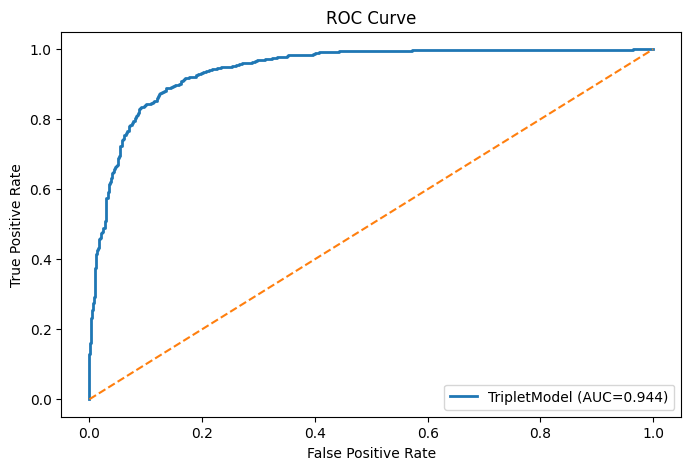

In [37]:
fpr, tpr, thresholds = roc_curve(y_true, y_pred)
auc = roc_auc_score(y_true, y_pred)

plt.figure(figsize=(8, 5))
plt.plot(fpr, tpr, lw=2, label=f'TripletModel (AUC={auc:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlim([-0.05, 1.05])
plt.ylim([-0.05, 1.05])

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")

plt.show()

### Precision-Recall Curve

The `precision-recall` analysis highlights the trade-off between correctly identifying matching pairs (recall) and avoiding false matches (precision).
As expected, lower thresholds increase recall but introduce more false positives, while higher thresholds improve precision at the cost of missing true matches.
This curve is useful for selecting an operating threshold depending on the application requirements.

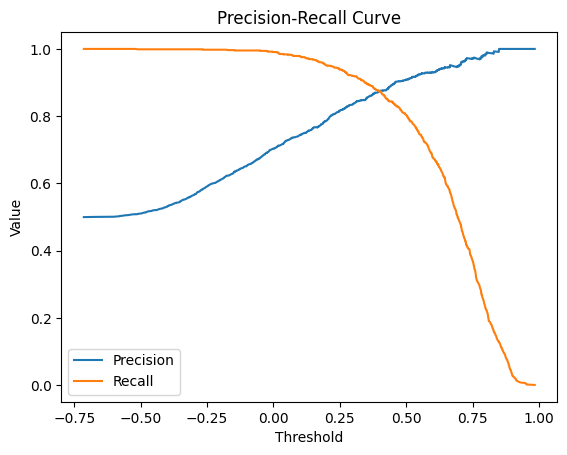

In [38]:
precision, recall, thresholds_pr = precision_recall_curve(y_true, y_pred)

plt.figure()
plt.plot(thresholds_pr, precision[:-1], label='Precision')
plt.plot(thresholds_pr, recall[:-1], label='Recall')

plt.xlabel('Threshold')
plt.ylabel('Value')
plt.title('Precision-Recall Curve')
plt.legend()

plt.show()

### Similarity Distribution

The similarity distribution plot shows the separation between positive pairs (same writer) and negative pairs (different writers) in the embedding space.
Positive pairs tend to have higher similarity values, while negative pairs are mostly concentrated in lower similarity regions.
This indicates that the model successfully learns a meaningful representation where samples from the same writer are closer in the feature space.

However, there is a noticeable overlap between the two distributions, particularly in the mid-range similarity values.
This overlap corresponds to ambiguous cases where the model struggles to distinguish between similar handwriting styles, leading to potential false positives and false negatives.

The degree of overlap explains why the model does not achieve perfect accuracy, despite the high AUC and triplet accuracy scores.
Reducing this overlap is key to further improving the model performance.

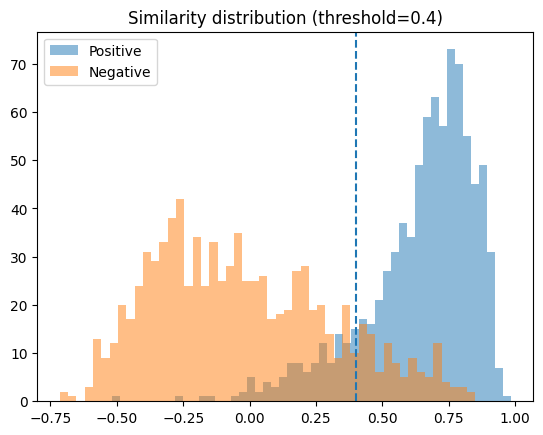

In [39]:
plt.hist(triplet_report.df_triplets["sim_ap"], bins=50, alpha=0.5, label="Positive")
plt.hist(triplet_report.df_triplets["sim_an"], bins=50, alpha=0.5, label="Negative")
plt.axvline(0.4, linestyle='--')
plt.legend()
plt.title("Similarity distribution (threshold=0.4)")
plt.show()

### Confusion Matrix

The `confusion matrix` provides insight into which writers are more frequently confused by the model.
Strong diagonal values indicate correct identification, while off-diagonal entries reveal pairs of writers with similar handwriting characteristics.
This analysis helps identify systematic errors and potential limitations of the learned embedding space.

**Triplet-level Confusion Matrix**

The first confusion matrix is computed from individual triplet predictions.

Each decision is based on a local comparison between a positive and a negative sample.

This matrix reflects how often the model assigns the correct writer label in pairwise similarity decisions.

Due to the local nature of these comparisons, the matrix may contain noise and variability.

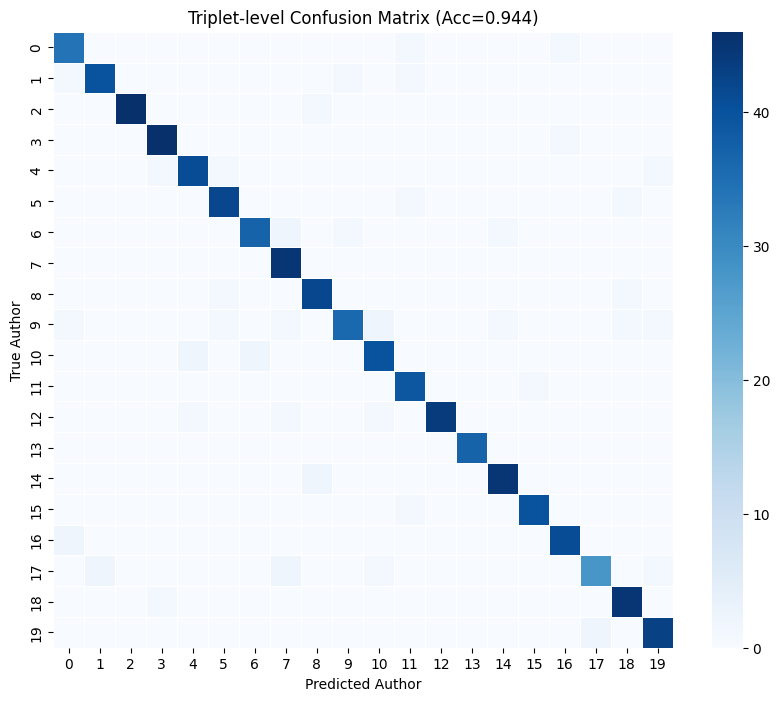

In [40]:
cm_df = build_author_confusion_matrix(
    triplet_report.df_triplets,
    true_col="anchor_label",
    pred_col="pred_label"
)
display_heatmap(cm_df, title="Triplet-level Confusion Matrix")

**Author-level Confusion Matrix**

The second confusion matrix is derived from aggregated metrics across triplets.

For each writer, the model selects the most representative prediction based on a scoring function combining accuracy and similarity gap.

This results in a more stable and global evaluation of the model’s ability to distinguish between different writers.

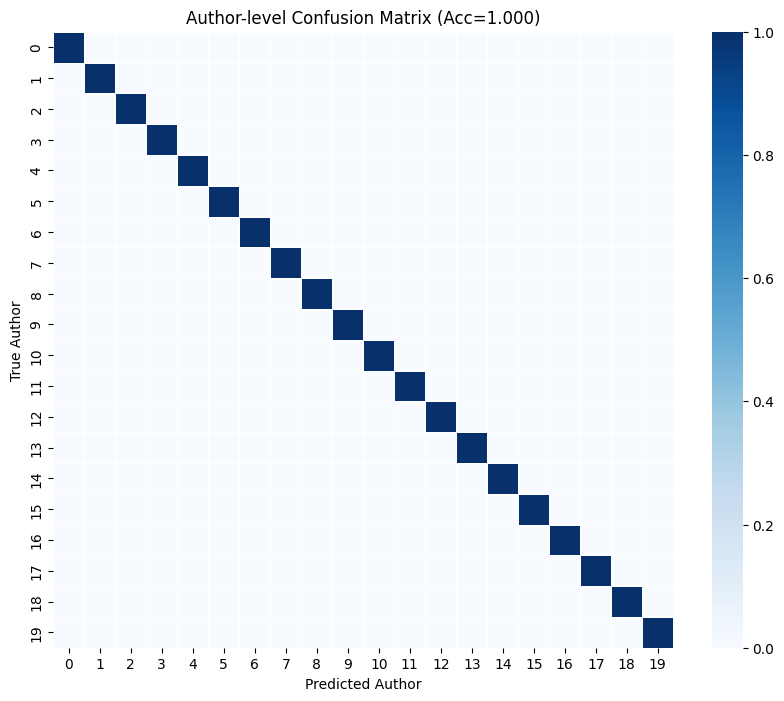

In [41]:
cm_df = build_author_confusion_matrix(
    triplet_report.global_metrics.df_by_score,
    true_col="anchor_label",
    pred_col="pred_label"
)
display_heatmap(cm_df, title="Author-level Confusion Matrix")

In [42]:
triplet_report.global_metrics.df_by_score

,anchor_label,pred_label,accuracy,mean_gap,count,gap_norm,score
0,0,0,1.0,0.900097,34,1.000000,1.000000
1,1,1,1.0,0.652350,40,0.845862,0.845862
2,2,2,1.0,0.831795,46,0.957506,0.957506
3,3,3,1.0,0.699438,46,0.875159,0.875159
4,4,4,1.0,0.687928,41,0.867998,0.867998
5,5,5,1.0,0.721738,42,0.889033,0.889033
6,6,6,1.0,0.569169,37,0.794111,0.794111
7,7,7,1.0,0.826655,45,0.954308,0.954308
8,8,8,1.0,0.760413,42,0.913095,0.913095
9,9,9,1.0,0.605489,36,0.816707,0.816707


In [43]:
val_gen = DataGenerator(
    split=val,
    batch_size=config.batch.validation,
    seed=config.training.seed,
    augment=augment
)
test_gen = DataGenerator(
    split=test,
    batch_size=config.batch.test,
    seed=config.training.seed,
    augment=augment
)

In [44]:
display_generator_info(val_gen)

10:48:58 - mobile_test_20_4 - INFO - Generator: DataGenerator
10:48:58 - mobile_test_20_4 - INFO - Number of samples: 3198
10:48:58 - mobile_test_20_4 - INFO - Batch size: 8
10:48:58 - mobile_test_20_4 - INFO - Steps per epoch: 400
10:48:58 - mobile_test_20_4 - INFO - Shape: (180, 360)
10:48:58 - mobile_test_20_4 - INFO - Number of authors: 20


In [45]:
display_generator_info(test_gen)

10:48:59 - mobile_test_20_4 - INFO - Generator: DataGenerator
10:48:59 - mobile_test_20_4 - INFO - Number of samples: 859
10:48:59 - mobile_test_20_4 - INFO - Batch size: 4
10:48:59 - mobile_test_20_4 - INFO - Steps per epoch: 215
10:48:59 - mobile_test_20_4 - INFO - Shape: (180, 360)
10:48:59 - mobile_test_20_4 - INFO - Number of authors: 20


## Embedding Evaluation

The main evaluation of the identification system.

**`EmbeddingExtractor`** uses `trainer.embedding_model` (not the full siamese network)
to extract one embedding per patch from the test set.

**Distance metrics:**
- `intra_distance` — average distance between patches from the **same** author
- `inter_distance` — average distance between patches from **different** authors
- A ratio `inter/intra >> 1` indicates good class separation in the embedding space

**Identification strategies:**
| Strategy | How it predicts the author of a patch |
|---|---|
| `1nn` | author of the nearest patch in the embedding space |
| `mean` | author whose mean embedding is most similar |
| `centroid` | author whose centroid (mean of train embeddings) is closest |
| `topk` | most frequent author among the K nearest neighbors |

**Aggregators — how predictions are aggregated at author level:**
| Aggregator | Logic |
|---|---|
| `patch` | accuracy per individual patch |
| `vote` | majority vote over all patches of the author |
| `score` | prediction by maximum average similarity |

> **The primary metric is `vote accuracy`.**
> Low patch accuracy (~60-80%) is expected and does not indicate model failure —
> an isolated patch can be ambiguous. Author identity emerges by aggregating
> evidence from multiple patches.

In [46]:
extractor = EmbeddingExtractor(
    model=trainer.embedding_model,
    logger=logger,
)

In [47]:
strategy_pipeline = StrategyPipeline(
    strategies=[
        OneNNStrategy(), MeanStrategy(), CentroidStrategy(), TopKStrategy(k=5),
    ],
    aggregators=[PatchAggregator(), VoteAggregator(), ScoreAggregator()],
    logger=logger,
)

In [48]:
emb_evaluator = EmbeddingEvaluator(
    extractor=extractor,
    pipeline=strategy_pipeline,
    logger=logger,
    seed=config.training.seed
)

In [49]:
val_gen_results = emb_evaluator.evaluate(val_gen)

10:49:29 - mobile_test_20_4 - INFO - [EmbeddingEvaluator] Starting evaluation
10:49:29 - mobile_test_20_4 - INFO - Extracting embeddings from the model
10:49:29 - mobile_test_20_4 - INFO - Processing 400 batches to extract embeddings
10:50:32 - mobile_test_20_4 - INFO - Extracted embeddings for 3198 samples
10:50:32 - mobile_test_20_4 - INFO - [EmbeddingEvaluator] Embeddings shape=(3198, 128)
10:50:32 - mobile_test_20_4 - INFO - [EmbeddingEvaluator] Computing intra/inter distances


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


10:50:54 - mobile_test_20_4 - INFO - [EmbeddingEvaluator] Evaluating strategies
10:50:54 - mobile_test_20_4 - INFO - Applying strategy pipeline with 4 strategies and 3 aggregators.
10:50:54 - mobile_test_20_4 - INFO - Applying strategy: 1nn
10:50:54 - mobile_test_20_4 - INFO - Applying aggregator: patch
10:50:54 - mobile_test_20_4 - INFO - Applying aggregator: vote
10:50:54 - mobile_test_20_4 - INFO - Applying aggregator: score
10:50:54 - mobile_test_20_4 - INFO - patch acc=0.6526Strategy '1nn' results: , vote acc=1.0000Strategy '1nn' results: , score acc=0.4500
10:50:54 - mobile_test_20_4 - INFO - Applying strategy: mean
10:50:55 - mobile_test_20_4 - INFO - Applying aggregator: patch
10:50:55 - mobile_test_20_4 - INFO - Applying aggregator: vote
10:50:55 - mobile_test_20_4 - INFO - Applying aggregator: score
10:50:55 - mobile_test_20_4 - INFO - patch acc=0.6354Strategy 'mean' results: , vote acc=0.8500Strategy 'mean' results: , score acc=0.4500
10:50:55 - mobile_test_20_4 - INFO - App

In [50]:
logger.info(f"Intra distance: {val_gen_results.intra_distance}")
logger.info(f"Inter distance: {val_gen_results.inter_distance}")

for strategy_name, agg_results in val_gen_results.strategy_results.items():

    logger.info(f"Strategy: {strategy_name}")

    for agg_name, result in agg_results.items():
        acc = result.metrics.get("accuracy", np.nan)
        logger.info(f"{agg_name.capitalize()} accuracy: {acc:.4f}")

    logger.info(f"{'-'*40}")

10:50:58 - mobile_test_20_4 - INFO - Intra distance: 0.40586355328559875
10:50:58 - mobile_test_20_4 - INFO - Inter distance: 0.9935901761054993
10:50:58 - mobile_test_20_4 - INFO - Strategy: 1nn
10:50:58 - mobile_test_20_4 - INFO - Patch accuracy: 0.6526
10:50:58 - mobile_test_20_4 - INFO - Vote accuracy: 1.0000
10:50:58 - mobile_test_20_4 - INFO - Score accuracy: 0.4500
10:50:58 - mobile_test_20_4 - INFO - ----------------------------------------
10:50:58 - mobile_test_20_4 - INFO - Strategy: mean
10:50:58 - mobile_test_20_4 - INFO - Patch accuracy: 0.6354
10:50:58 - mobile_test_20_4 - INFO - Vote accuracy: 0.8500
10:50:58 - mobile_test_20_4 - INFO - Score accuracy: 0.4500
10:50:58 - mobile_test_20_4 - INFO - ----------------------------------------
10:50:58 - mobile_test_20_4 - INFO - Strategy: centroid
10:50:58 - mobile_test_20_4 - INFO - Patch accuracy: 0.6795
10:50:58 - mobile_test_20_4 - INFO - Vote accuracy: 1.0000
10:50:58 - mobile_test_20_4 - INFO - Score accuracy: 0.5000
10:

In [51]:
test_gen_results = emb_evaluator.evaluate(test_gen)

10:50:58 - mobile_test_20_4 - INFO - [EmbeddingEvaluator] Starting evaluation
10:50:58 - mobile_test_20_4 - INFO - Extracting embeddings from the model
10:50:58 - mobile_test_20_4 - INFO - Processing 215 batches to extract embeddings
10:51:31 - mobile_test_20_4 - INFO - Extracted embeddings for 859 samples
10:51:31 - mobile_test_20_4 - INFO - [EmbeddingEvaluator] Embeddings shape=(859, 128)
10:51:31 - mobile_test_20_4 - INFO - [EmbeddingEvaluator] Computing intra/inter distances


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


10:51:34 - mobile_test_20_4 - INFO - [EmbeddingEvaluator] Evaluating strategies
10:51:34 - mobile_test_20_4 - INFO - Applying strategy pipeline with 4 strategies and 3 aggregators.
10:51:34 - mobile_test_20_4 - INFO - Applying strategy: 1nn
10:51:34 - mobile_test_20_4 - INFO - Applying aggregator: patch
10:51:34 - mobile_test_20_4 - INFO - Applying aggregator: vote
10:51:34 - mobile_test_20_4 - INFO - Applying aggregator: score
10:51:34 - mobile_test_20_4 - INFO - patch acc=0.8522Strategy '1nn' results: , vote acc=1.0000Strategy '1nn' results: , score acc=0.6500
10:51:34 - mobile_test_20_4 - INFO - Applying strategy: mean
10:51:34 - mobile_test_20_4 - INFO - Applying aggregator: patch
10:51:34 - mobile_test_20_4 - INFO - Applying aggregator: vote
10:51:34 - mobile_test_20_4 - INFO - Applying aggregator: score
10:51:34 - mobile_test_20_4 - INFO - patch acc=0.7090Strategy 'mean' results: , vote acc=0.8500Strategy 'mean' results: , score acc=0.4000
10:51:34 - mobile_test_20_4 - INFO - App

In [52]:
logger.info(f"Intra distance: {test_gen_results.intra_distance}")
logger.info(f"Inter distance: {test_gen_results.inter_distance}")

for strategy_name, agg_results in test_gen_results.strategy_results.items():

    logger.info(f"Strategy: {strategy_name}")

    for agg_name, result in agg_results.items():
        acc = result.metrics.get("accuracy", np.nan)
        logger.info(f"{agg_name.capitalize()} accuracy: {acc:.4f}")

    logger.info(f"{'-'*40}")

10:51:34 - mobile_test_20_4 - INFO - Intra distance: 0.34056556224823
10:51:34 - mobile_test_20_4 - INFO - Inter distance: 1.0202528238296509
10:51:34 - mobile_test_20_4 - INFO - Strategy: 1nn
10:51:34 - mobile_test_20_4 - INFO - Patch accuracy: 0.8522
10:51:34 - mobile_test_20_4 - INFO - Vote accuracy: 1.0000
10:51:34 - mobile_test_20_4 - INFO - Score accuracy: 0.6500
10:51:34 - mobile_test_20_4 - INFO - ----------------------------------------
10:51:34 - mobile_test_20_4 - INFO - Strategy: mean
10:51:34 - mobile_test_20_4 - INFO - Patch accuracy: 0.7090
10:51:34 - mobile_test_20_4 - INFO - Vote accuracy: 0.8500
10:51:34 - mobile_test_20_4 - INFO - Score accuracy: 0.4000
10:51:34 - mobile_test_20_4 - INFO - ----------------------------------------
10:51:34 - mobile_test_20_4 - INFO - Strategy: centroid
10:51:34 - mobile_test_20_4 - INFO - Patch accuracy: 0.7590
10:51:34 - mobile_test_20_4 - INFO - Vote accuracy: 1.0000
10:51:34 - mobile_test_20_4 - INFO - Score accuracy: 0.4500
10:51:

## Visualization and Error Analysis

`EmbeddingVisualizer` allows exploring the embedding space and model errors.

- `plot_embeddings_2d()` — UMAP projection of the embedding space, colored by author
- `plot_centroids()` — centroid of each author in UMAP space
- `log_error_samples()` — patches misclassified at patch level
- `plot_confusion()` — confusion matrix by `aggregators`

> Patch-level errors are informative: they reveal which authors have similar styles
> or nearby embeddings in the learned space.
> If vote accuracy is high despite patch errors, the model is working correctly —
> individual patch ambiguity is resolved by majority aggregation.

In [53]:
viz = EmbeddingVisualizer(
    report=test_gen_results,
    logger=logger,
    split=test,
)

In [54]:
viz.set_strategy("1nn")

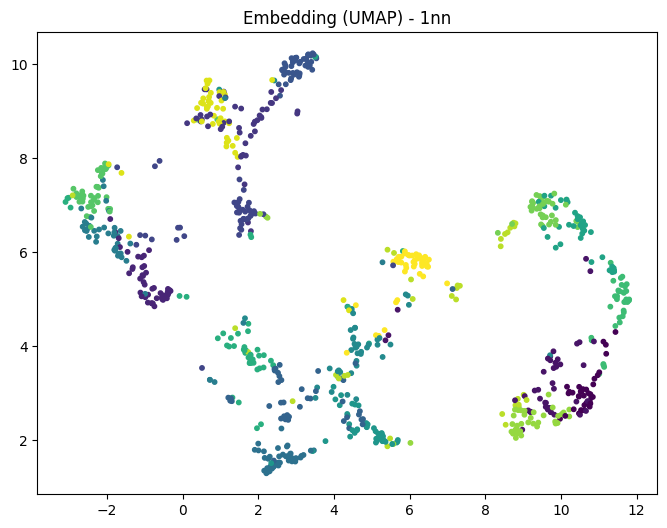

In [55]:
viz.plot_embeddings()

In [56]:
viz.log_error_samples(n=10)

10:51:35 - mobile_test_20_4 - INFO - Showing 10 error samples:
10:51:35 - mobile_test_20_4 - INFO - [idx=366] true=lines1_Page_09 pred=lines1_Page_15 (author_id=8 → 14)
10:51:35 - mobile_test_20_4 - INFO - [idx=55] true=lines1_Page_02 pred=lines1_Page_14 (author_id=1 → 13)
10:51:35 - mobile_test_20_4 - INFO - [idx=278] true=lines1_Page_07 pred=lines1_Page_18 (author_id=6 → 17)
10:51:35 - mobile_test_20_4 - INFO - [idx=405] true=lines1_Page_10 pred=lines1_Page_19 (author_id=9 → 18)
10:51:35 - mobile_test_20_4 - INFO - [idx=151] true=lines1_Page_04 pred=lines1_Page_19 (author_id=3 → 18)
10:51:35 - mobile_test_20_4 - INFO - [idx=173] true=lines1_Page_05 pred=lines1_Page_20 (author_id=4 → 19)
10:51:35 - mobile_test_20_4 - INFO - [idx=459] true=lines1_Page_11 pred=lines1_Page_10 (author_id=10 → 9)
10:51:35 - mobile_test_20_4 - INFO - [idx=272] true=lines1_Page_07 pred=lines1_Page_13 (author_id=6 → 12)
10:51:35 - mobile_test_20_4 - INFO - [idx=395] true=lines1_Page_10 pred=lines1_Page_07 (au

10:51:35 - mobile_test_20_4 - INFO - Estimated DBSCAN eps=1.0043 | clusters=4 | min_samples=2


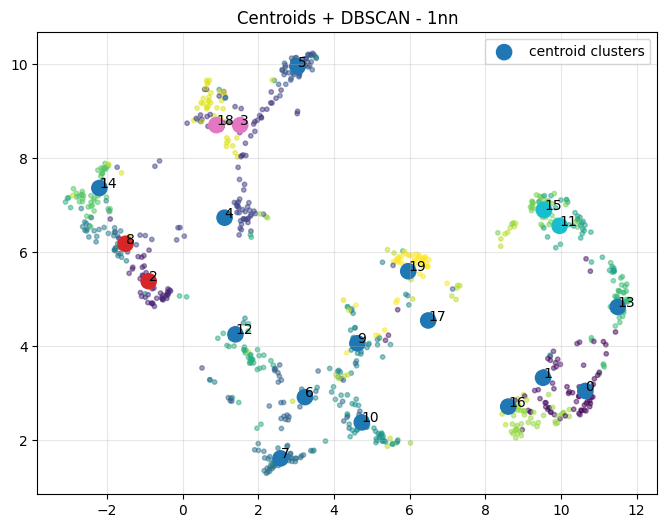

In [57]:
viz.plot_centroids()

**Patch-level Confusion Matrix**

The patch-level confusion matrix evaluates the model’s predictions on individual image patches.

Since each patch contains only partial handwriting information, predictions at this level are inherently noisy.

This results in noticeable confusion between authors with similar local stroke patterns.

10:52:44 - mobile_test_20_4 - INFO - 1nn - by patch accuracy 0.85


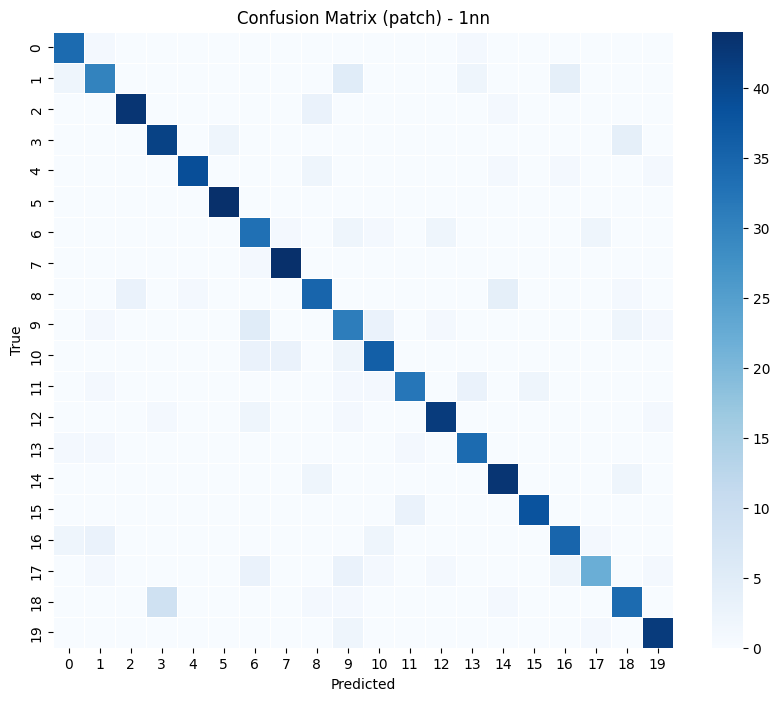

In [59]:
one_nn_patch_acc = test_gen_results.strategy_results['1nn']['patch'].metrics
logger.info(f"1nn - by patch accuracy {one_nn_patch_acc['accuracy']:.2f}")
viz.plot_confusion(level="patch")

**Vote-level Confusion Matrix**

The vote-level confusion matrix represents the final classification performance after aggregating predictions across multiple patches.

By combining information from several patches, the model achieves more robust and stable predictions, significantly reducing classification errors.

10:53:10 - mobile_test_20_4 - INFO - 1nn - by vote accuracy 1.0


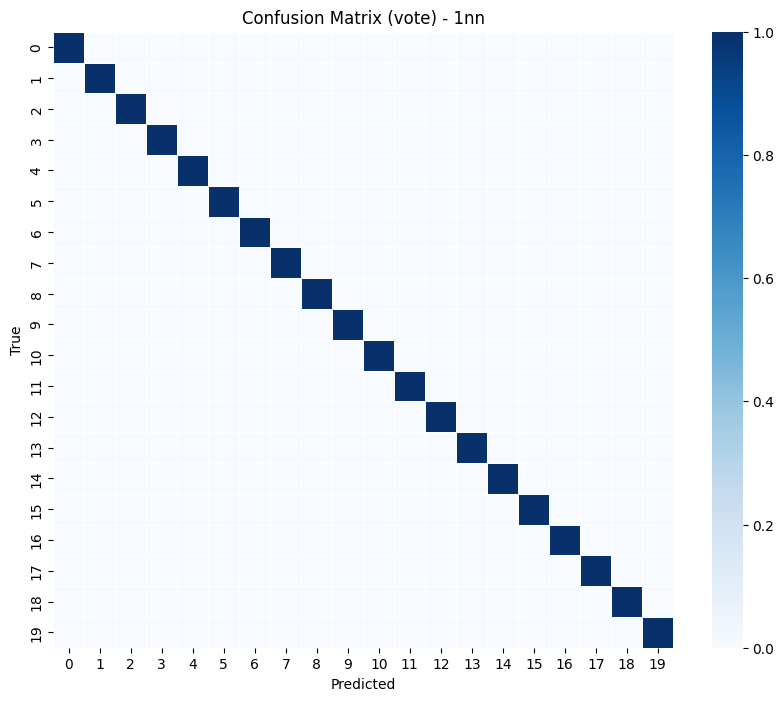

In [60]:
one_nn_vote_acc = test_gen_results.strategy_results['1nn']['vote'].metrics
logger.info(f"1nn - by vote accuracy {one_nn_vote_acc['accuracy']}")
viz.plot_confusion(level="vote")

**Score-level Confusion Matrix**

The score-level aggregation provides a more principled decision mechanism by incorporating both correctness frequency and confidence (gap) into a unified score.

This leads to improved discrimination between writers, especially in cases where simple majority voting may be ambiguous.

10:53:47 - mobile_test_20_4 - INFO - 1nn - by score accuracy 0.65


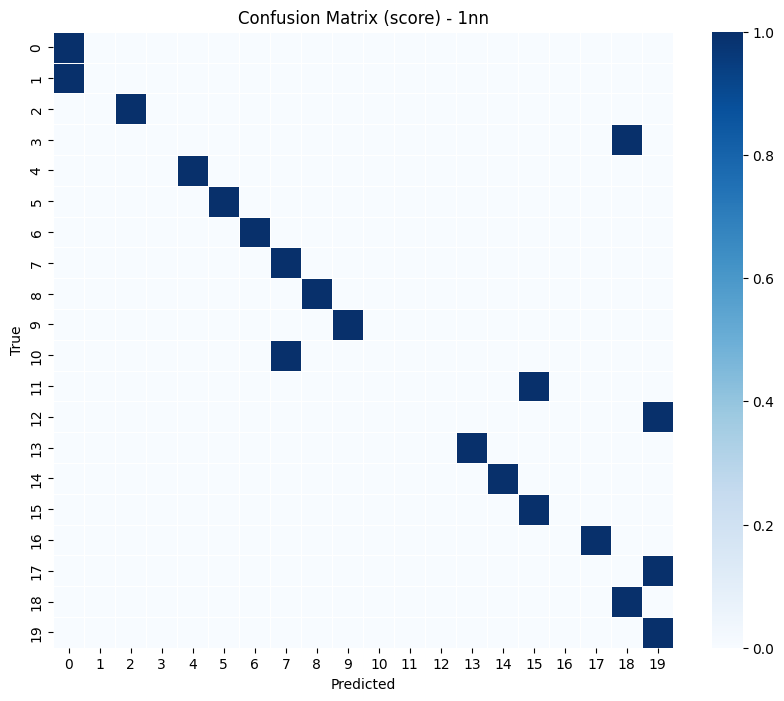

In [61]:
one_nn_score_acc = test_gen_results.strategy_results['1nn']['score'].metrics
logger.info(f"1nn - by score accuracy {one_nn_score_acc['accuracy']:.2f}")
viz.plot_confusion(level="score")

**Comparison**

The comparison between patch-level, vote-level, and score-level confusion matrices highlights the progressive impact of aggregation strategies on model performance.

At the patch level, predictions are based on local image regions and are therefore noisy and often ambiguous. This results in higher confusion between writers with similar local handwriting patterns.

The vote-level aggregation improves performance by combining multiple patch predictions, reducing random errors through majority voting. This leads to more stable and reliable writer identification.

The score-level aggregation further refines this process by incorporating confidence information, using both accuracy and similarity gap to select the most representative prediction. Unlike voting, this approach accounts for the quality of predictions, not just their frequency.

As a result, score-level aggregation provides the most robust and discriminative performance, especially in cases where vote-level decisions may still be uncertain.

In [62]:
res_1nn_data = test_gen_results.strategy_results['1nn']['score'].data
one_nn_error_data = res_1nn_data[res_1nn_data['correct'] == False]
one_nn_error_data[['author', 'author_pred']]

,author,author_pred
1,1,0
3,3,18
10,10,7
11,11,15
12,12,19
16,16,17
17,17,19


10:58:52 - mobile_test_20_4 - INFO - Estimated DBSCAN eps=1.0043 | clusters=4 | min_samples=2


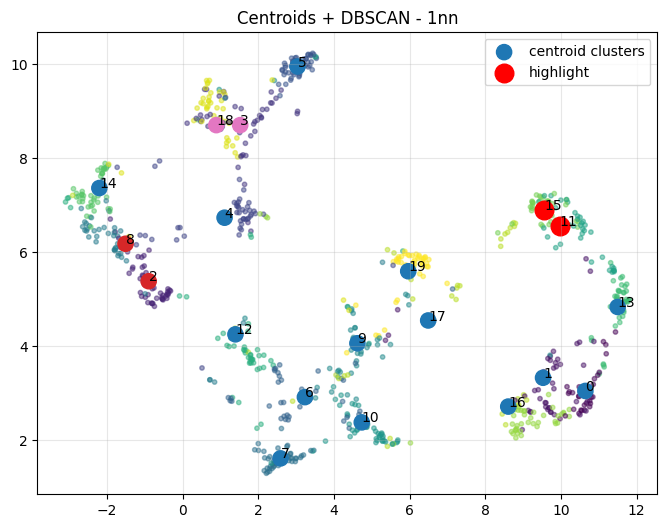

In [70]:
viz.plot_centroids([11, 15])

10:55:47 - mobile_test_20_4 - INFO - Estimated DBSCAN eps=1.0043 | clusters=4 | min_samples=2


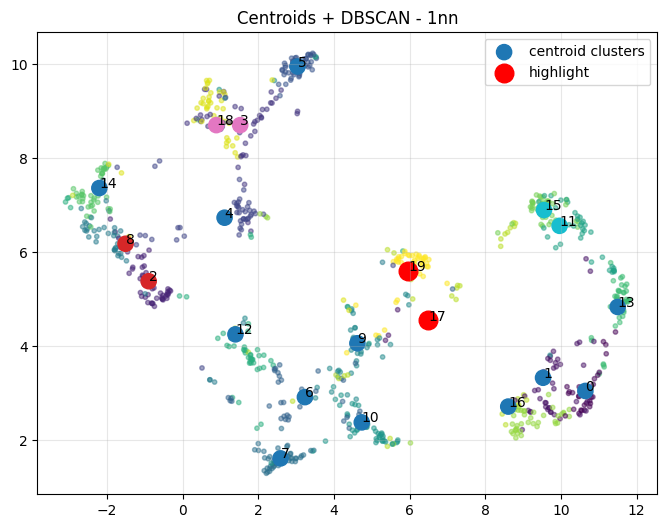

In [65]:
viz.plot_centroids([17, 19])

In [67]:
patches = viz.df_base[viz.df_base["author"] == 17]
df_idx = patches.index[0]
viz.show_nearest(df_idx, k=10)

10:57:12 - mobile_test_20_4 - INFO - Query idx=635 | author=lines1_Page_15
10:57:12 - mobile_test_20_4 - INFO - Top-K nearest:
10:57:12 - mobile_test_20_4 - INFO - 1. [idx=635] lines1_Page_15 | sim=1.0000 | ✓
10:57:12 - mobile_test_20_4 - INFO - 2. [idx=634] lines1_Page_15 | sim=0.9412 | ✓
10:57:12 - mobile_test_20_4 - INFO - 3. [idx=619] lines1_Page_15 | sim=0.9284 | ✓
10:57:12 - mobile_test_20_4 - INFO - 4. [idx=620] lines1_Page_15 | sim=0.9225 | ✓
10:57:12 - mobile_test_20_4 - INFO - 5. [idx=618] lines1_Page_15 | sim=0.9223 | ✓
10:57:12 - mobile_test_20_4 - INFO - 6. [idx=643] lines1_Page_15 | sim=0.9199 | ✓
10:57:12 - mobile_test_20_4 - INFO - 7. [idx=377] lines1_Page_09 | sim=0.9187 | ✗
10:57:12 - mobile_test_20_4 - INFO - 8. [idx=387] lines1_Page_09 | sim=0.9185 | ✗
10:57:12 - mobile_test_20_4 - INFO - 9. [idx=623] lines1_Page_15 | sim=0.9168 | ✓
10:57:12 - mobile_test_20_4 - INFO - 10. [idx=624] lines1_Page_15 | sim=0.9110 | ✓


In [68]:
patches = viz.df_base[viz.df_base["author"] == 11]
df_idx = patches.index[0]
viz.show_nearest(df_idx, k=10)

10:58:03 - mobile_test_20_4 - INFO - Query idx=594 | author=lines1_Page_14
10:58:03 - mobile_test_20_4 - INFO - Top-K nearest:
10:58:03 - mobile_test_20_4 - INFO - 1. [idx=594] lines1_Page_14 | sim=1.0000 | ✓
10:58:03 - mobile_test_20_4 - INFO - 2. [idx=595] lines1_Page_14 | sim=0.9180 | ✓
10:58:03 - mobile_test_20_4 - INFO - 3. [idx=497] lines1_Page_12 | sim=0.9074 | ✗
10:58:03 - mobile_test_20_4 - INFO - 4. [idx=576] lines1_Page_14 | sim=0.9052 | ✓
10:58:03 - mobile_test_20_4 - INFO - 5. [idx=499] lines1_Page_12 | sim=0.8953 | ✗
10:58:03 - mobile_test_20_4 - INFO - 6. [idx=574] lines1_Page_14 | sim=0.8830 | ✓
10:58:03 - mobile_test_20_4 - INFO - 7. [idx=575] lines1_Page_14 | sim=0.8817 | ✓
10:58:03 - mobile_test_20_4 - INFO - 8. [idx=584] lines1_Page_14 | sim=0.8759 | ✓
10:58:03 - mobile_test_20_4 - INFO - 9. [idx=583] lines1_Page_14 | sim=0.8695 | ✓
10:58:03 - mobile_test_20_4 - INFO - 10. [idx=573] lines1_Page_14 | sim=0.8585 | ✓
